<div align="center">
    <h1>QUBO &amp; Ising Models</h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <i>Universities Space Research Association</i>
    <br>
    <i>NASA QuAIL</i>
    <br>
    <br>
    <a href="https://github.com/pedromxavier">Pedro Maciel Xavier</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <i>Computer Science &amp; Systems Engineering Program, Federal University of Rio de Janeiro</i>
    <br>
    <i>PSR Energy Consulting &amp; Analytics</i>
    <br>
    <br>
    <a href="https://github.com/jvpcms">João Victor Souza</a>
    <br>
    <i>Computer Engineering Department, Military Institute of Engineering (IME)</i>
    <br>
    <br>
    <a href="https://colab.research.google.com/github/SECQUOIA/QuIP/blob/main/notebooks_jl/2-QUBO.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

**Environment setup**

For local execution from the repository root, run `uv sync --group qubo` and `make setup-julia` before launching Jupyter. The Julia QUBO notebook reuses the repo-local Python environment for `dwave-neal`, instead of relying on Julia's `CondaPkg` resolver.

If you open this notebook in Google Colab, make sure the runtime is set to **Julia** before running the next cell.
The setup cell will clone `SECQUOIA/QuIP` into the Colab workspace when needed, activate `notebooks_jl/Project.toml`, install the Julia packages used in this notebook, and install the Python `dwave-neal` package into the Python runtime that `PythonCall.jl` will reuse.


In [ ]:
import Pkg

IN_COLAB = haskey(ENV, "COLAB_RELEASE_TAG") || haskey(ENV, "COLAB_JUPYTER_IP")

function detect_quip_repo_dir()
    candidates = (pwd(), normpath(pwd(), ".."))

    for candidate in candidates
        if isfile(joinpath(candidate, "notebooks_jl", "Project.toml"))
            return candidate
        end
    end

    error("Could not locate the QuIP repository root from $(pwd()).")
end

QUIP_REPO_DIR = if IN_COLAB
    repo_dir = get(ENV, "QUIP_REPO_DIR", joinpath(pwd(), "QuIP"))

    if !isdir(repo_dir)
        run(`git clone --depth 1 https://github.com/SECQUOIA/QuIP.git $repo_dir`)
    end

    repo_dir
else
    detect_quip_repo_dir()
end

JULIA_NOTEBOOKS_DIR = joinpath(QUIP_REPO_DIR, "notebooks_jl")

if IN_COLAB
    run(`python3 -m pip install -q dwave-neal`)
    ENV["JULIA_PYTHONCALL_EXE"] = something(Sys.which("python3"), "python3")
else
    repo_python = joinpath(QUIP_REPO_DIR, ".venv", "bin", "python3")
    if !isfile(repo_python)
        error("Could not find $(repo_python). Run `uv sync --group qubo` from the repository root before launching this notebook.")
    end
    ENV["JULIA_PYTHONCALL_EXE"] = repo_python
end

ENV["JULIA_CONDAPKG_BACKEND"] = "Null"

Pkg.activate(JULIA_NOTEBOOKS_DIR)
Pkg.instantiate(; io = devnull)

cd(JULIA_NOTEBOOKS_DIR)


In [ ]:
using Karnak


In [ ]:
using LinearAlgebra


In [ ]:
using Graphs


In [ ]:
using JuMP


In [ ]:
using QUBO


In [ ]:
using Plots


In [ ]:
using GLPK


In [ ]:
using DWaveNeal, PythonCall

# DWaveNeal.jl assumes an older dwave-neal return type for `variables`.
# Patch the sampler method locally so the notebook keeps working with the
# current Python package used by the repo and by Colab.
function DWaveNeal.sample(sampler::DWaveNeal.Optimizer{T}) where {T}
    Q, α, β = DWaveNeal.qubo(sampler, Dict)
    n = DWaveNeal.MOI.get(sampler, DWaveNeal.MOI.NumberOfVariables())

    params = Dict{Symbol,Any}(
        param => DWaveNeal.MOI.get(sampler, DWaveNeal.MOI.RawOptimizerAttribute(string(param)))
        for param in DWaveNeal._DWAVE_NEAL_ATTR_LIST
    )

    neal_sampler = DWaveNeal.neal.SimulatedAnnealingSampler()
    results = @timed neal_sampler.sample_qubo(Q; params...)
    var_map = pyconvert(Vector{Int}, pylist(results.value.variables))

    samples = Vector{DWaveNeal.Sample{T,Int}}()

    for (ϕ, λ, r) in results.value.record
        ψ = zeros(Int, n)

        for (i, v) in enumerate(ϕ)
            ψ[var_map[i]] = pyconvert(Int, v)
        end

        push!(samples, DWaveNeal.Sample{T,Int}(
            ψ,
            α * (pyconvert(T, λ) + β),
            pyconvert(Int, r),
        ))
    end

    metadata = Dict{String,Any}(
        "origin" => "D-Wave Neal",
        "time" => Dict{String,Any}("effective" => results.time),
    )

    return DWaveNeal.SampleSet{T,Int}(samples, metadata)
end


In [ ]:
using Luxor


## Quadratic Unconstrained Binary Optimization

This notebook explains the basics of QUBO modeling.
In order to implement the different QUBO formulations we will use **[JuMP](https://jump.dev)**, and then solve them using **[neal](https://github.com/dwavesystems/dwave-neal)**'s implementation of simulated annealing.
We will also leverage **[QUBO.jl](https://github.com/psrenergy/QUBO.jl)** to translate constraint satisfaction problems to QUBOs.
Finally, we will use **[Graphs.jl](https://github.com/JuliaGraphs/Graphs.jl)** for network models and graph visualizations.


## Problem statement

We define a QUBO as the following optimization problem:

$$
\min_{x \in \{0,1 \}^n} \sum_{(ij) \in E(G)} Q_{ij}x_i x_j + \sum_{i \in V(G)}Q_{ii}x_i + \beta = \min_{x \in \{0,1 \}^n}  \mathbf{x}' \mathbf{Q} \mathbf{x} + \beta
$$

where we optimize over binary variables $x \in \{ 0,1 \}^n$, on a constrained graph $G(V,E)$ defined by a weighted adjacency matrix $\mathbf{Q}$.
We also include an arbitrary offset  $\beta$.

### Example

Suppose we want to solve the following problem via QUBO

$$
\begin{array}{rl}
\displaystyle%
\min_{\mathbf{x}} & 2x_0+4x_1+4x_2+4x_3+4x_4+4x_5+5x_6+4x_7+5x_8+6x_9+5x_{10} \\
\textrm{s.t.}     & \begin{bmatrix}
1 & 0 & 0 & 1 & 1 & 1 & 0 & 1 & 1 & 1 & 1\\
0 & 1 & 0 & 1 & 0 & 1 & 1 & 0 & 1 & 1 & 1\\
0 & 0 & 1 & 0 & 1 & 0 & 1 & 1 & 1 & 1 & 1
\end{bmatrix}\mathbf{x}=
\begin{bmatrix}
1\\
1\\
1
\end{bmatrix} \\
~ & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

First we would write this problem as an unconstrained one by penalizing the linear constraints as quadratics in the objective.
Let's first define the problem parameters.


In [15]:
A = [
    1 0 0 1 1 1 0 1 1 1 1
    0 1 0 1 0 1 1 0 1 1 1
    0 0 1 0 1 0 1 1 1 1 1
]
b = [1, 1, 1]
c = [2, 4, 4, 4, 4, 4, 5, 4, 5, 6, 5];

In order to define the $\mathbf{Q}$ matrix, we first write the problem

$$
\begin{array}{rl}
    \displaystyle%
    \min_{\mathbf{x}} &\mathbf{c}' \mathbf{x} \\
    \textrm{s.t.}     & \mathbf{A}\mathbf{x} = \mathbf{b} \\
    ~                 & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

as follows:

$$
\begin{array}{rl}
    \displaystyle%
    \min_{\mathbf{x}} & \mathbf{c}' \mathbf{x} + \rho (\mathbf{A}\mathbf{x}-\mathbf{b})' (\mathbf{A}\mathbf{x}-\mathbf{b}) \\
    \textrm{s.t.}     & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

Exploiting the fact that $x^2=x$ for $x \in \{0,1\}$, we can make the linear terms appear in the diagonal of the $\mathbf{Q}$ matrix.

$$
\rho(\mathbf{A}\mathbf{x}-\mathbf{b})'(\mathbf{A}\mathbf{x}-\mathbf{b}) = \rho( \mathbf{x}'(\mathbf{A}'\mathbf{A}) \mathbf{x} - 2(\mathbf{A}'\mathbf{b}) \mathbf{x} + \mathbf{b}'\mathbf{b} )
$$

For this problem in particular, one can prove that a reasonable penalization factor is given by $\rho = \sum_{i=1}^n |c_i| + \epsilon$ with $\epsilon > 0$.

In [16]:
ϵ = 1
ρ = sum(abs, c) + ϵ
Q = diagm(c) + ρ * (A'A - 2 * diagm(A'b))
β = ρ * b'b

display(Q)
println(β)

11×11 Matrix{Int64}:
 -46    0    0   48   48   48    0   48    48    48    48
   0  -44    0   48    0   48   48    0    48    48    48
   0    0  -44    0   48    0   48   48    48    48    48
  48   48    0  -92   48   96   48   48    96    96    96
  48    0   48   48  -92   48   48   96    96    96    96
  48   48    0   96   48  -92   48   48    96    96    96
   0   48   48   48   48   48  -91   48    96    96    96
  48    0   48   48   96   48   48  -92    96    96    96
  48   48   48   96   96   96   96   96  -139   144   144
  48   48   48   96   96   96   96   96   144  -138   144
  48   48   48   96   96   96   96   96   144   144  -139

144


We can visualize the graph that defines this instance using the $\mathbf{Q}$ matrix as the adjacency matrix of a graph.

In [17]:
G = SimpleGraph(Q)
println(G)

SimpleGraph{Int64}(58, [[1, 4, 5, 6, 8, 9, 10, 11], [2, 4, 6, 7, 9, 10, 11], [3, 5, 7, 8, 9, 10, 11], [1, 2, 4, 5, 6, 7, 8, 9, 10, 11], [1, 3, 4, 5, 6, 7, 8, 9, 10, 11], [1, 2, 4, 5, 6, 7, 8, 9, 10, 11], [2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [1, 3, 4, 5, 6, 7, 8, 9, 10, 11], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]])


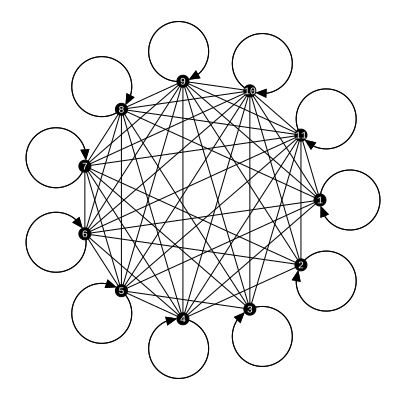

In [18]:
@drawsvg(
    begin
        sethue("black")
        background("white")
        drawgraph(
            G;
            margin       = 80,
            vertexlabels = 1:11,
        )
    end,
    400, 400
)

Let's define a QUBO model and then solve it using enumeration and D-Wave's simulated annealing (and, eventually, quantum annealing too!).


In [19]:
# Define empty model
qubo_model = Model()

# Define the variables
@variable(qubo_model, x[1:11], Bin)

# Define the objective function
@objective(qubo_model, Min, x' * Q * x + β)

# Print the model
print(qubo_model)

Since the problem is relatively small ($11$ variables, $2^{11}=2048$ combinations), we can afford to enumerate all the solutions.

In [20]:
# Here we solve the optimization problem with GLPK
set_optimizer(qubo_model, ExactSampler.Optimizer)

optimize!(qubo_model)

qubo_x = round.(Int, value.(x))

# Display solution of the problem
println(solution_summary(qubo_model))
println("* x = $qubo_x")

solution_summary(; result = 1, verbose = false)
├ solver_name          : Exact Sampler
├ Termination
│ ├ termination_status : LOCALLY_SOLVED
│ ├ result_count       : 2048
│ └ raw_status         : optimal
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : NO_SOLUTION
│ ├ objective_value      : 5.00000e+00
│ └ dual_objective_value : 1.44000e+02
└ Work counters
  └ solve_time (sec)   : 2.48074e-01
* x = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


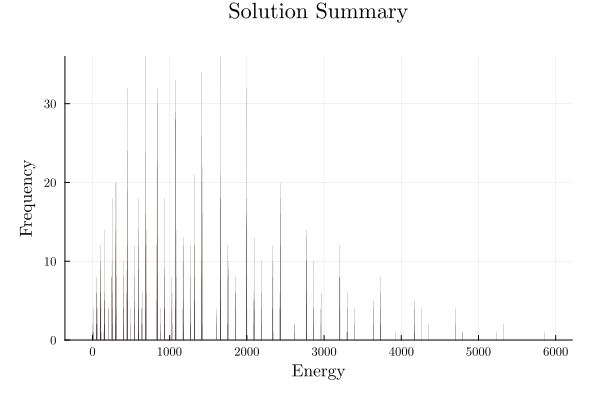

In [21]:
plot(QUBOTools.sampleset(unsafe_backend(qubo_model)))


Let's now solve this QUBO via traditional Integer Programming.

In [22]:
qubo_ilp_model = Model()

@variable(qubo_ilp_model, x[1:11], Bin)
@variable(qubo_ilp_model, y[1:11, 1:11], Bin)

@objective(
    qubo_ilp_model,
    Min,
    sum(Q[i,j] * (i == j ? x[i] : y[i,j]) for i=1:11, j=1:11) +  β
)

@constraint(qubo_ilp_model, c1[i=1:11,j=1:11;i!=j], y[i,j] >= x[i] + x[j] - 1)
@constraint(qubo_ilp_model, c2[i=1:11,j=1:11;i!=j], y[i,j] <= x[i])
@constraint(qubo_ilp_model, c3[i=1:11,j=1:11;i!=j], y[i,j] <= x[j])

println(qubo_ilp_model)

Min -46 x[1] + 48 y[1,4] + 48 y[1,5] + 48 y[1,6] + 48 y[1,8] + 48 y[1,9] + 48 y[1,10] + 48 y[1,11] - 44 x[2] + 48 y[2,4] + 48 y[2,6] + 48 y[2,7] + 48 y[2,9] + 48 y[2,10] + 48 y[2,11] - 44 x[3] + 48 y[3,5] + 48 y[3,7] + 48 y[3,8] + 48 y[3,9] + 48 y[3,10] + 48 y[3,11] + 48 y[4,1] + 48 y[4,2] - 92 x[4] + 48 y[4,5] + 96 y[4,6] + 48 y[4,7] + 48 y[4,8] + 96 y[4,9] + [[...45 terms omitted...]] + 96 y[9,4] + 96 y[9,5] + 96 y[9,6] + 96 y[9,7] + 96 y[9,8] - 139 x[9] + 144 y[9,10] + 144 y[9,11] + 48 y[10,1] + 48 y[10,2] + 48 y[10,3] + 96 y[10,4] + 96 y[10,5] + 96 y[10,6] + 96 y[10,7] + 96 y[10,8] + 144 y[10,9] - 138 x[10] + 144 y[10,11] + 48 y[11,1] + 48 y[11,2] + 48 y[11,3] + 96 y[11,4] + 96 y[11,5] + 96 y[11,6] + 96 y[11,7] + 96 y[11,8] + 144 y[11,9] + 144 y[11,10] - 139 x[11] + 144
Subject to
 c1[1,2] : -x[1] - x[2] + y[1,2] ≥ -1
 c1[1,3] : -x[1] - x[3] + y[1,3] ≥ -1
 c1[1,4] : -x[1] - x[4] + y[1,4] ≥ -1
 c1[1,5] : -x[1] - x[5] + y[1,5] ≥ -1
 c1[1,6] : -x[1] - x[6] + y[1,6] ≥ -1
 c1[1,7] : -x[

In [23]:
set_optimizer(qubo_ilp_model, GLPK.Optimizer)

optimize!(qubo_ilp_model)

qubo_ilp_x = round.(Int, value.(x))

println(solution_summary(qubo_ilp_model))
println("* x = $qubo_ilp_x")

solution_summary(; result = 1, verbose = false)
├ solver_name          : GLPK
├ Termination
│ ├ termination_status : OPTIMAL
│ ├ result_count       : 1
│ ├ raw_status         : Solution is optimal
│ └ objective_bound    : 5.00000e+00
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : NO_SOLUTION
│ ├ objective_value      : 5.00000e+00
│ └ relative_gap         : 9.60000e+00
└ Work counters
  └ solve_time (sec)   : 1.55139e-02
* x = [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]


We observe that the minimum QUBO energy is $5$. In 1-based indexing, the two minimizing binary solutions have either $x_9 = 1$ or $x_{11} = 1$, with all other entries equal to $0$.


## Ising model

This notebook explains the basics of the Ising model.
In order to implement the different Ising models we will use **[JuMP](https://jump.dev)** and D-Wave's **[neal](https://github.com/dwavesystems/dwave-neal)**, for defining the Ising model and solving it with simulated annealing, respectively.
When posing the problem as an integer program, we convert it to an equivalent binary QUBO formulation and then solve that MILP with the open-source **[GLPK](https://www.gnu.org/software/glpk/)** solver.


### Problem statement

We pose the Ising problem as the following optimization problem:

$$
\min_{s \in \{ \pm 1 \}^n} H(s) = \min_{s \in \{ \pm 1 \}^n} \sum_{(i, j) \in E(G)} J_{i,j}s_is_j + \sum_{i \in V(G)} h_is_i + \beta
$$

where we optimize over spins $s \in \{ \pm 1 \}^n$, on a constrained graph $G(V,E)$, where the quadratic coefficients are $J_{i,j}$ and the linear coefficients are $h_i$.
We also include an arbitrary offset of the Ising model $\beta$.

### Example

Suppose we have an Ising model defined from

$$
h = \begin{bmatrix}
145.0 \\ 122.0 \\ 122.0 \\ 266.0 \\ 266.0 \\ 266.0 \\ 242.5 \\ 266.0 \\ 386.5 \\ 387.0 \\ 386.5
\end{bmatrix},
J = \begin{bmatrix}
0 & 0 & 0 & 24 & 24 & 24 & 24 & 24 & 24 & 24 & 24\\
0 & 0 & 0 & 24 & 0 & 24 & 24 & 24 & 24 & 24 & 24\\
0 & 0 & 0 & 0 & 24 & 0 & 24 & 24 & 24 & 24 & 24\\
0 & 0 & 0 & 0 & 24 & 48 & 24 & 24 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 24 & 24 & 48 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 0 & 24 & 24 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 24 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 48 & 48 & 48\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 72 & 72\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 72\\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0\\
\end{bmatrix} \text{ and }
\beta = 1319.5
$$
Let's solve this problem

In [24]:
h = [
    145.0,
    122.0,
    122.0,
    266.0,
    266.0,
    266.0,
    242.5,
    266.0,
    386.5,
    387.0,
    386.5,
]

J = [
    0  0  0 24 24 24  0 24 24 24 24
    0  0  0 24  0 24 24  0 24 24 24
    0  0  0  0 24  0 24 24 24 24 24
    0  0  0  0 24 48 24 24 48 48 48
    0  0  0  0  0 24 24 48 48 48 48
    0  0  0  0  0  0 24 24 48 48 48
    0  0  0  0  0  0  0 24 48 48 48
    0  0  0  0  0  0  0  0 48 48 48
    0  0  0  0  0  0  0  0  0 72 72
    0  0  0  0  0  0  0  0  0  0 72
    0  0  0  0  0  0  0  0  0  0  0
]

β = 1319.5

ising_model = Model()

@variable(ising_model, s[1:11], Spin)

@objective(ising_model, Min, s' * J * s + h' * s + β)

println(ising_model)

Min 24 s[4]*s[1] + 24 s[4]*s[2] + 24 s[5]*s[1] + 24 s[5]*s[3] + 24 s[5]*s[4] + 24 s[6]*s[1] + 24 s[6]*s[2] + 48 s[6]*s[4] + 24 s[6]*s[5] + 24 s[7]*s[2] + 24 s[7]*s[3] + 24 s[7]*s[4] + 24 s[7]*s[5] + 24 s[7]*s[6] + 24 s[8]*s[1] + 24 s[8]*s[3] + 24 s[8]*s[4] + 48 s[8]*s[5] + 24 s[8]*s[6] + 24 s[8]*s[7] + 24 s[9]*s[1] + 24 s[9]*s[2] + 24 s[9]*s[3] + 48 s[9]*s[4] + 48 s[9]*s[5] + 48 s[9]*s[6] + 48 s[9]*s[7] + 48 s[9]*s[8] + 24 s[10]*s[1] + 24 s[10]*s[2] + 24 s[10]*s[3] + 48 s[10]*s[4] + 48 s[10]*s[5] + 48 s[10]*s[6] + 48 s[10]*s[7] + 48 s[10]*s[8] + 72 s[10]*s[9] + 24 s[11]*s[1] + 24 s[11]*s[2] + 24 s[11]*s[3] + 48 s[11]*s[4] + 48 s[11]*s[5] + 48 s[11]*s[6] + 48 s[11]*s[7] + 48 s[11]*s[8] + 72 s[11]*s[9] + 72 s[11]*s[10] + 145 s[1] + 122 s[2] + 122 s[3] + 266 s[4] + 266 s[5] + 266 s[6] + 242.5 s[7] + 266 s[8] + 386.5 s[9] + 387 s[10] + 386.5 s[11] + 1319.5
Subject to
 s[1] spin
 s[2] spin
 s[3] spin
 s[4] spin
 s[5] spin
 s[6] spin
 s[7] spin
 s[8] spin
 s[9] spin
 s[10] spin
 s[11] spin



In [25]:
set_optimizer(ising_model, ExactSampler.Optimizer)

optimize!(ising_model)

ising_s = round.(Int, value.(s))

# Display solution of the problem
println(solution_summary(ising_model))
println("* s = $ising_s")

solution_summary(; result = 1, verbose = false)
├ solver_name          : Exact Sampler
├ Termination
│ ├ termination_status : LOCALLY_SOLVED
│ ├ result_count       : 2048
│ └ raw_status         : optimal
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : NO_SOLUTION
│ ├ objective_value      : 5.00000e+00
│ └ dual_objective_value : 1.31950e+03
└ Work counters
  └ solve_time (sec)   : 1.48198e-03
* s = [-1, -1, -1, -1, -1, -1, -1, -1, 1, -1, -1]


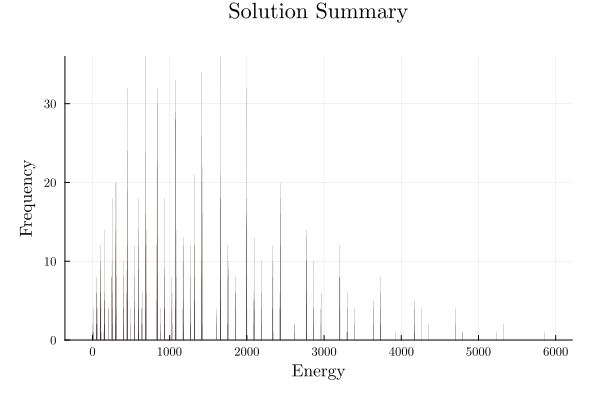

In [26]:
plot(QUBOTools.sampleset(unsafe_backend(ising_model)))


In [27]:
Q, α, β = QUBOTools.qubo(unsafe_backend(ising_model), Matrix)


QUBOTools.Form{Float64, QUBOTools.DenseLinearForm{Float64}, QUBOTools.DenseQuadraticForm{Float64}}(11, QUBOTools.DenseLinearForm{Float64}([-46.0, -44.0, -44.0, -92.0, -92.0, -92.0, -91.0, -92.0, -139.0, -138.0, -139.0]), QUBOTools.DenseQuadraticForm{Float64}([0.0 0.0 … 96.0 96.0; 0.0 0.0 … 96.0 96.0; … ; 0.0 0.0 … 0.0 288.0; 0.0 0.0 … 0.0 0.0]), 1.0, 144.0, QUBOTools.Frame(QUBOTools.Min, QUBOTools.BoolDomain))

In [28]:
ising_ilp_model = Model()

@variable(ising_ilp_model, x[1:11], Bin)
@variable(ising_ilp_model, y[1:11, 1:11], Bin)

@objective(
    ising_ilp_model,
    Min,
    α * sum(Q[i,j] * (i == j ? x[i] : y[i,j]) for i=1:11, j=1:11) + β
)

@constraint(ising_ilp_model, c1[i=1:11,j=1:11;i!=j], y[i,j] >= x[i] + x[j] - 1)
@constraint(ising_ilp_model, c2[i=1:11,j=1:11;i!=j], y[i,j] <= x[i])
@constraint(ising_ilp_model, c3[i=1:11,j=1:11;i!=j], y[i,j] <= x[j])

println(ising_ilp_model)


Min 96 y[1,4] + 96 y[1,5] + 96 y[1,6] + 96 y[1,8] + 96 y[1,9] + 96 y[1,10] + 96 y[1,11] + 96 y[2,4] + 96 y[2,6] + 96 y[2,7] + 96 y[2,9] + 96 y[2,10] + 96 y[2,11] + 96 y[3,5] + 96 y[3,7] + 96 y[3,8] + 96 y[3,9] + 96 y[3,10] + 96 y[3,11] + 96 y[4,5] + 192 y[4,6] + 96 y[4,7] + 96 y[4,8] + 192 y[4,9] + 192 y[4,10] + 192 y[4,11] + 96 y[5,6] + 96 y[5,7] + 192 y[5,8] + 192 y[5,9] + 192 y[5,10] + 192 y[5,11] + 96 y[6,7] + 96 y[6,8] + 192 y[6,9] + 192 y[6,10] + 192 y[6,11] + 96 y[7,8] + 192 y[7,9] + 192 y[7,10] + 192 y[7,11] + 192 y[8,9] + 192 y[8,10] + 192 y[8,11] + 288 y[9,10] + 288 y[9,11] + 288 y[10,11] + 144
Subject to
 c1[1,2] : -x[1] - x[2] + y[1,2] ≥ -1
 c1[1,3] : -x[1] - x[3] + y[1,3] ≥ -1
 c1[1,4] : -x[1] - x[4] + y[1,4] ≥ -1
 c1[1,5] : -x[1] - x[5] + y[1,5] ≥ -1
 c1[1,6] : -x[1] - x[6] + y[1,6] ≥ -1
 c1[1,7] : -x[1] - x[7] + y[1,7] ≥ -1
 c1[1,8] : -x[1] - x[8] + y[1,8] ≥ -1
 c1[1,9] : -x[1] - x[9] + y[1,9] ≥ -1
 c1[1,10] : -x[1] - x[10] + y[1,10] ≥ -1
 c1[1,11] : -x[1] - x[11] + y[1,

In [29]:
set_optimizer(ising_ilp_model, GLPK.Optimizer)

optimize!(ising_ilp_model)

ising_ilp_x = round.(Int, value.(x))

println(solution_summary(ising_ilp_model))
println("* x = $ising_ilp_x")

solution_summary(; result = 1, verbose = false)
├ solver_name          : GLPK
├ Termination
│ ├ termination_status : OPTIMAL
│ ├ result_count       : 1
│ ├ raw_status         : Solution is optimal
│ └ objective_bound    : 1.44000e+02
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : NO_SOLUTION
│ ├ objective_value      : 1.44000e+02
│ └ relative_gap         : 0.00000e+00
└ Work counters
  └ solve_time (sec)   : 3.80993e-04
* x = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


We observe that the minimum Ising energy is $5$. In spin variables, the two minimizing states have either $s_9 = 1$ or $s_{11} = 1$, with all other spins equal to $-1$.
After converting the Ising model to the binary QUBO form for the integer-programming solve, those same minima appear as $x_9 = 1$ or $x_{11} = 1$, with all other binary variables equal to $0$.


## Let's go back to the slides

Let's now solve the QUBO problem using Simulated Annealing

In [30]:
set_optimizer(qubo_model, DWaveNeal.Optimizer)

set_optimizer_attribute(qubo_model, "num_reads", 1_000)

optimize!(qubo_model)

x = qubo_model[:x]

qubo_x = round.(Int, value.(x))

println(solution_summary(qubo_model))
println("* x = $qubo_x")


solution_summary(; result = 1, verbose = false)
├ solver_name          : D-Wave Neal Simulated Annealing Sampler
├ Termination
│ ├ termination_status : LOCALLY_SOLVED
│ ├ result_count       : 12
│ └ raw_status         : 
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : NO_SOLUTION
│ ├ objective_value      : 5.00000e+00
│ └ dual_objective_value : 1.44000e+02
└ Work counters
  └ solve_time (sec)   : 8.89956e-01
* x = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


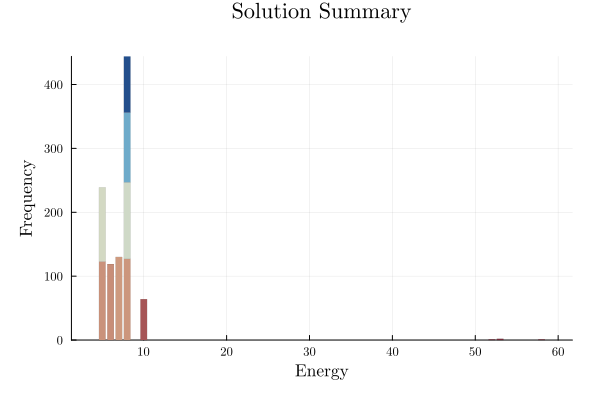

In [31]:
plot(QUBOTools.sampleset(unsafe_backend(qubo_model)))


Notice that this is the same example we have been solving earlier (via Integer Programming in the Quiz 1 and Ising model above).

## Let's go back to the slides

Let's solve the graph coloring problem in the slides using QUBO.

#### Vertex $k$-coloring of graphs

Given a graph $G(V, E)$, where $V$ is the set of vertices and $E$ is the set of edges of $G$, and a positive integer $k$, we ask if it is possible to assign a color to every vertex from $V$, such that adjacent vertices have different colors assigned.

$G(V, E)$ has $12$ vertices and $23$ edges.
We ask if the graph is $3$–colorable.
Let’s first encode $V$ and $E$ using Julia’s built–in data structures:

**Note:** This second tutorial is heavily inspired by D-Wave's Map coloring of Canada found **[here](https://docs.ocean.dwavesys.com/en/stable/examples/map_coloring.html)**.


In [32]:
V = 1:12
E = [
    (1,2), (1,4), (1,6), (1,12),
    (2,3), (2,5), (2,7),
    (3,8), (3,10),
    (4,9), (4,11),
    (5,6), (5,9), (5,12),
    (6,7), (6,10),
    (7,8), (7,11),
    (8,9), (8,12),
    (9,10),
    (10,11),
    (11,12),
]

G = SimpleGraph(Edge.(E))

{12, 23} undirected simple Int64 graph

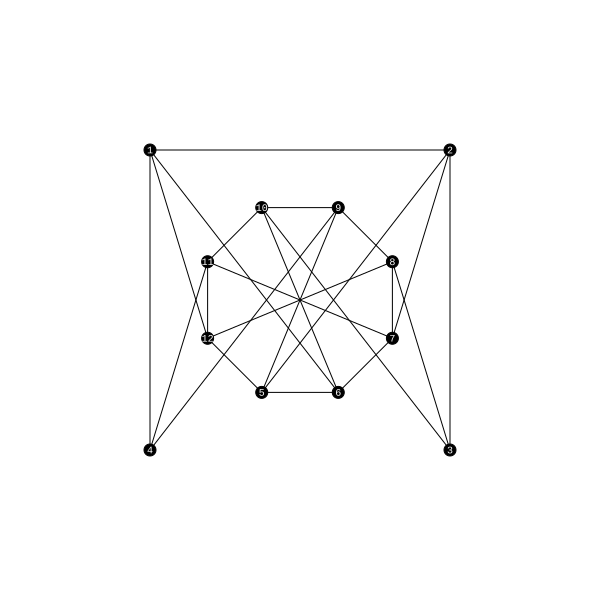

In [33]:
graph_layout = Vector{Point}(undef, 12)

graph_layout[1] = Point(-1.5,-1.5)
graph_layout[2] = Point(1.5,-1.5)
graph_layout[3] = Point(1.5,1.5)
graph_layout[4] = Point(-1.5,1.5)

for i in 5:12
    graph_layout[i] = Point(cos((2i+1) * π/8), -sin((2i+1) * π/8))
end

@drawsvg(
    begin
        sethue("black")
        background("white")
        drawgraph(
            G;
            layout=100 * graph_layout,
            vertexlabels = V,
        )
    end,
)

In [34]:
# Valid configurations for the constraint that each node select a single color, in this case we want to use 3 colors
color_model = Model()

@variable(color_model, c[1:12,1:3], Bin)

# Each node must be colored with exactly one color
@constraint(color_model, unique[i=1:12], sum(c[i,:]) == 1)

# Add constraint that each pair of nodes with a shared edge not both select one color
@constraint(color_model, neigh[(i,j) ∈ E, k=1:3], c[i, k] * c[j,k] == 0)

2-dimensional DenseAxisArray{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarQuadraticFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape},2,...} with index sets:
    Dimension 1, [(1, 2), (1, 4), (1, 6), (1, 12), (2, 3), (2, 5), (2, 7), (3, 8), (3, 10), (4, 9)  …  (5, 12), (6, 7), (6, 10), (7, 8), (7, 11), (8, 9), (8, 12), (9, 10), (10, 11), (11, 12)]
    Dimension 2, Base.OneTo(3)
And data, a 23×3 Matrix{ConstraintRef{Model, MathOptInterface.ConstraintIndex{MathOptInterface.ScalarQuadraticFunction{Float64}, MathOptInterface.EqualTo{Float64}}, ScalarShape}}:
 neigh[(1, 2),1] : c[1,1]*c[2,1] = 0      …  neigh[(1, 2),3] : c[1,3]*c[2,3] = 0
 neigh[(1, 4),1] : c[1,1]*c[4,1] = 0         neigh[(1, 4),3] : c[1,3]*c[4,3] = 0
 neigh[(1, 6),1] : c[1,1]*c[6,1] = 0         neigh[(1, 6),3] : c[1,3]*c[6,3] = 0
 neigh[(1, 12),1] : c[1,1]*c[12,1] = 0       neigh[(1, 12),3] : c[1,3]*c[12,3] = 0
 neigh[(2, 3),1] : c[2,1]*c[3,1] = 0         neigh[(2, 3),3] : c

In [35]:
set_optimizer(color_model, () -> ToQUBO.Optimizer(DWaveNeal.Optimizer))

optimize!(color_model)

color_ρ = get_optimizer_attribute.(neigh, ToQUBO.Attributes.ConstraintEncodingPenalty())

color_c = round.(Int, value.(c))

println(solution_summary(color_model))
println("* c = $color_c")
println("* ρ = $color_ρ")


solution_summary(; result = 1, verbose = false)
├ solver_name          : Virtual QUBO Model
├ Termination
│ ├ termination_status : LOCALLY_SOLVED
│ ├ result_count       : 176
│ └ raw_status         : 
├ Solution (result = 1)
│ ├ primal_status        : FEASIBLE_POINT
│ ├ dual_status          : NO_SOLUTION
│ └ objective_value      : 0.00000e+00
└ Work counters
  └ solve_time (sec)   : 9.87178e-01
* c = [0 1 0; 0 0 1; 1 0 0; 1 0 0; 0 1 0; 0 0 1; 1 0 0; 0 1 0; 0 0 1; 0 1 0; 0 0 1; 1 0 0]
* ρ = 2-dimensional DenseAxisArray{Float64,2,...} with index sets:
    Dimension 1, [(1, 2), (1, 4), (1, 6), (1, 12), (2, 3), (2, 5), (2, 7), (3, 8), (3, 10), (4, 9)  …  (5, 12), (6, 7), (6, 10), (7, 8), (7, 11), (8, 9), (8, 12), (9, 10), (10, 11), (11, 12)]
    Dimension 2, Base.OneTo(3)
And data, a 23×3 Matrix{Float64}:
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1.0  1.0
 1.0  1

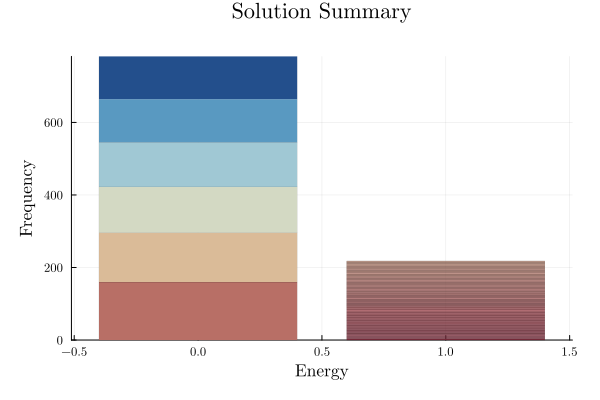

In [42]:
plot(QUBOTools.sampleset(unsafe_backend(color_model).optimizer))


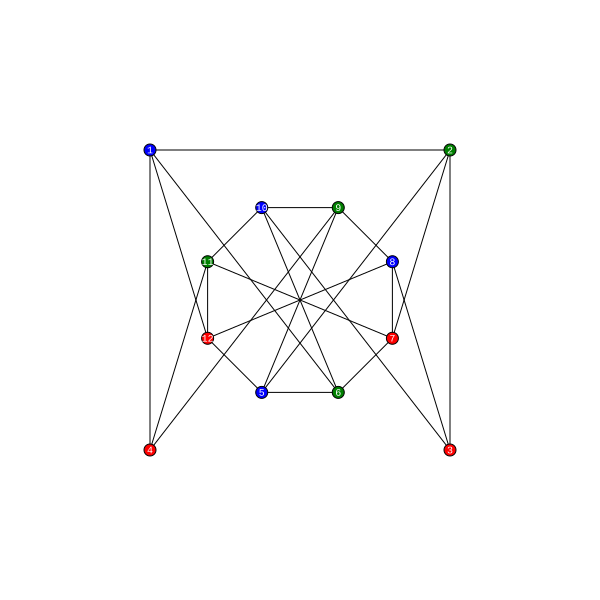

In [38]:
@drawsvg(
    begin
        sethue("black")
        background("white")
        drawgraph(
            G;
            layout=100 * graph_layout,
            vertexlabels = V,
            vertexfillcolors = (v) -> begin
                if color_c[v,1] > 0
                    return colorant"red"
                elseif color_c[v,2] > 0
                    return colorant"blue"
                elseif color_c[v,3] > 0
                    return colorant"green"
                else
                    return colorant"white"
                end
            end
        )
    end,
)

# References

- [QUBO.jl](https://github.com/psrenergy/QUBO.jl/)
- [D-Wave Ocean: Map Coloring](https://docs.ocean.dwavesys.com/en/stable/examples/map_coloring.html)
- [SECQUOIA/QuIP](https://github.com/SECQUOIA/QuIP)
